# Figure 6 — Detection performance (injection truth + MER catalogue)

Combined detection-performance figure for the CenterNet head on the **frozen** foundation's
fused 10-band bottleneck (SEP round-1 labels), evaluated on the **108 patch-disjoint
held-out tiles** at threshold $0.30$ throughout.

- **(a)** Point-source completeness vs VIS magnitude. Solid curves are **source-recycling
  injection with star-like donors** (isolated, unresolved: concentration $C\geq0.65$, pool
  19.5–22.5; all 10 bands / VIS only / NISP only), the honest point-source measurement after
  the 2026-07 donor-morphology audit (`io/22`; the legacy 19.5–21.5 donor pool was compact
  *galaxies*, so the old curve was an extended-morphology completeness — quoted in the paper
  text but no longer drawn here). Black diamonds are the
  validation: real sources re-injected at native brightness, no dimming. Dashed curve =
  recovery of the real clean-MER catalogue; gray histogram = MER VIS-mag distribution.
  Point-source 50% depth: all-band $\approx26.6$ vs VIS-only $\approx26.1$ (+0.45 mag fusion
  gain, same as in the extended regime: 25.0 vs 24.6).
- **(b)** Completeness vs **measured** VIS aperture S/N (no magnitude zeropoint).
- **(c)** Operating point: completeness (VIS<24.5) and purity vs detection threshold.

Reads `injection_metrics_r30_star{,_deep}.json` (star donors), `mer_recovery.json`, `bakeoff_metrics.json`, and the nb22
validation cache. Saves `paper/figures/fig6_detection_performance.png` — single source of truth.

In [1]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

def find_repo_root(s=None):
    s=(s or Path.cwd()).resolve()
    for c in [s,*s.parents]:
        if (c/'models').exists() and (c/'data').exists(): return c
    raise FileNotFoundError('repo root')
REPO=find_repo_root()
D   = REPO/'checkpoints'/'q1_detection'          # production detector = CenterNet + SEP labels
OUT = REPO/'paper'/'figures'/'fig6_detection_performance.png'
for p in ('injection_metrics_r30_star.json','injection_metrics_r30_star_deep.json',
          'mer_recovery.json','bakeoff_metrics.json'):
    assert (D/p).exists(), f'missing Q1 metric: {D/p}  (run models/detection eval first)'
_star = json.load(open(D/'injection_metrics_r30_star.json'))['cn_vis_sep']['curves']
_deep = json.load(open(D/'injection_metrics_r30_star_deep.json'))['cn_vis_sep']['curves']
inj = {m: {'mag': _star[m]['mag'] + _deep[m]['mag'],
           'comp': _star[m]['comp'] + _deep[m]['comp']} for m in ('all','vis','nisp')}
rec = json.load(open(D/'mer_recovery.json'))                       # MER recovery + S/N + hist
bak = json.load(open(D/'bakeoff_metrics.json'))['cn_vis_sep']['rows']  # conf sweep
# real-source (no dimming) validation points from the nb22 audit cache
_v = json.load(open(REPO/'io'/'_nb22_outputs'/'records.json'))
VBINS = (23.0, 23.5, 24.0, 24.5, 25.0)
_t = {m: [0, 0] for m in VBINS}
for tr in _v.values():
    if 'skip' in tr: continue
    for m in VBINS:
        r, n = tr['nodim'][str(m)]; _t[m][0] += r; _t[m][1] += n
val_comp = np.array([100*_t[m][0]/max(_t[m][1],1) for m in VBINS])
val_err  = 100*np.sqrt(val_comp/100*(1-val_comp/100)/np.array([max(_t[m][1],1) for m in VBINS]))
print('Q1 metrics loaded from', D, '| star-donor point-source curves + nb22 validation')

Q1 metrics loaded from /home/shemmati/Work/Projects/JAISP/checkpoints/q1_detection | star-donor point-source curves + nb22 validation


saved /home/shemmati/Work/Projects/JAISP/paper/figures/fig6_detection_performance.png


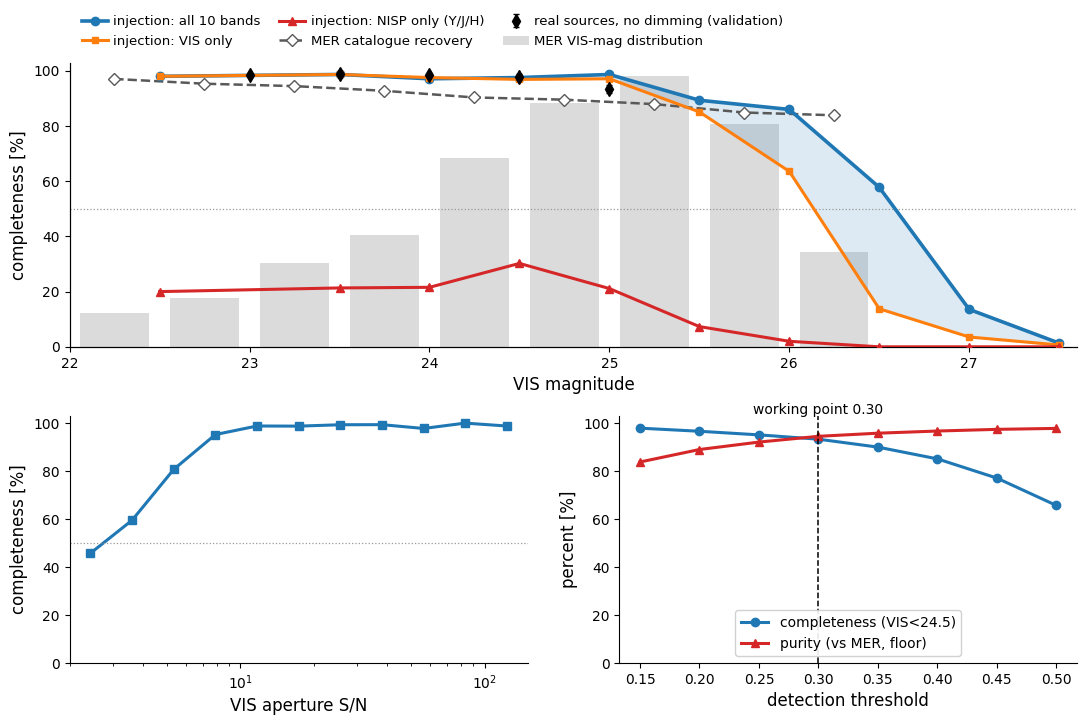

In [2]:
# ---- assemble the 3-panel figure (a: wide top, b/c: bottom) ----
CA, CV, CN, CP = '#1f77b4', '#ff7f0e', '#d62728', '#d62728'
fig = plt.figure(figsize=(13, 7.8))
gs = fig.add_gridspec(2, 2, height_ratios=[1.15, 1.0], hspace=0.26, wspace=0.2)
a = fig.add_subplot(gs[0, :]); b = fig.add_subplot(gs[1, 0]); c = fig.add_subplot(gs[1, 1])

# ---- (a) completeness vs VIS magnitude ----
medges = np.array(rec['medges']); hc = (medges[:-1] + medges[1:]) / 2
at = a.twinx()
at.bar(hc, rec['mer_hist'], width=0.38, color='0.86', zorder=0, label='MER VIS-mag distribution')
at.set_yticks([])   # histogram is illustrative context; no right-axis scale needed
a.set_zorder(at.get_zorder() + 1); a.patch.set_visible(False)
mag = np.array(inj['all']['mag'])
cu = {k: np.array(inj[k]['comp']) for k in ('all', 'vis', 'nisp')}
a.fill_between(mag, cu['vis'], cu['all'], color=CA, alpha=0.15, zorder=2)
a.plot(mag, cu['all'], '-o', color=CA, lw=2.6, ms=6, label='injection: all 10 bands', zorder=5)
a.plot(mag, cu['vis'], '-s', color=CV, lw=2.2, ms=5, label='injection: VIS only', zorder=5)
a.plot(mag, cu['nisp'], '-^', color=CN, lw=2.2, ms=6, label='injection: NISP only (Y/J/H)', zorder=5)
a.plot(rec['rec_mag'], rec['rec_comp'], '--D', color='0.35', lw=1.8, ms=6, mfc='white', zorder=4,
       label='MER catalogue recovery')
a.errorbar(VBINS, val_comp, val_err, fmt='d', color='k', ms=7, capsize=2.5, zorder=6, lw=1.2,
           label='real sources, no dimming (validation)')
a.axhline(50, color='0.6', lw=0.9, ls=':')
a.set_xlim(22, 27.6); a.set_ylim(0, 103)
a.set_xlabel('VIS magnitude', fontsize=12); a.set_ylabel('completeness [%]', fontsize=12)
a.tick_params(labelsize=10)
h1, l1 = a.get_legend_handles_labels(); h2, l2 = at.get_legend_handles_labels()
a.legend(h1 + h2, l1 + l2, fontsize=9.5, loc='lower left', bbox_to_anchor=(0.0, 1.01),
         ncol=3, frameon=False, columnspacing=1.4, handletextpad=0.4)

# ---- (b) completeness vs measured VIS aperture S/N ----
b.plot(rec['snr_x'], rec['snr_comp'], '-s', color=CA, lw=2.2, ms=6)
b.axhline(50, color='0.6', lw=0.9, ls=':'); b.set_xscale('log'); b.set_ylim(0, 103)
b.set_xlabel('VIS aperture S/N', fontsize=12); b.set_ylabel('completeness [%]', fontsize=12)
b.tick_params(labelsize=10)

# ---- (c) completeness & purity vs threshold ----
keys = sorted(bak, key=float); confs = [float(k) for k in keys]
comp = [bak[k]['completeness'] for k in keys]; pur = [bak[k]['purity'] for k in keys]
c.plot(confs, comp, '-o', color=CA, lw=2.2, ms=6, label='completeness (VIS<24.5)')
c.plot(confs, pur, '-^', color=CP, lw=2.2, ms=6, label='purity (vs MER, floor)')
c.axvline(0.30, color='k', lw=1.1, ls='--')
c.text(0.30, 104, 'working point 0.30', fontsize=10, ha='center', color='k')
c.set_ylim(0, 103); c.set_xlabel('detection threshold', fontsize=12); c.set_ylabel('percent [%]', fontsize=12)
c.tick_params(labelsize=10); c.legend(fontsize=10, loc='lower center', frameon=True, framealpha=0.9)

for x in (a, b, c):
    for s in ('top', 'right'): x.spines[s].set_visible(False)
for s in ('top', 'right'): at.spines[s].set_visible(False)

OUT.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(OUT, dpi=200, bbox_inches='tight', facecolor='white')
print('saved', OUT)
plt.show()